In [299]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import math

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType: text stays editable in Illustrator/Inkscape
mpl.rcParams['ps.fonttype'] = 42    # same for .eps/.ps
mpl.rcParams['svg.fonttype'] = 'none'  # if you ever save .svg: keep text as text

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']  # first one installed wins


['/mnt/ceph/users/blyo1/projects/hdiva', '/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages', '/tmp/tmp4fc4r2tk']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# new

In [274]:
# PLOT SAVE DIRECTORY
plot_save_loc = os.path.join(notebook_dir, "d_analysis", "sami_autoprior", "plots")
os.makedirs(plot_save_loc, exist_ok=True)
print(plot_save_loc)

/mnt/ceph/users/blyo1/projects/hdiva/d_analysis/sami_autoprior/plots


In [276]:
from b_models.autoprior.utils import load_trained_sami_autoprior

# model_num is the leading number of the run dir in
# c_training/lightning_checkpoints/sami_autoprior_celeba_64/, e.g. 2 -> "2-eager-eon-2-u02iqu2g"
sami_ap, sami_config = load_trained_sami_autoprior(model_num=2, checkpoint="last", device=device)
# a specific epoch:  checkpoint="0049"
# from wandb:        load_trained_sami_autoprior(model_num=2, from_wandb=True, artifact_id="latest", device=device)

print(sami_config.rate_type, sami_config.beta_final)


loaded /mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/sami_autoprior_celeba_64/2-eager-eon-2-u02iqu2g/last.ckpt (epoch 284)
norm 0.001


In [277]:
from b_models.autoprior.utils import load_model_args_from_artifact, load_autoprior_weights
from a_datasets.celeba_old.data import load_celeba_old_data

_, args, model_path = load_model_args_from_artifact('blyo', 'autoprior_celeba_64', 'autoprior_celeba_64', 'v77')
v77 = load_autoprior_weights(args, model_path, device).eval()

# images after the first 60000 were not used for training; values in [0, 1]
test_imgs = load_celeba_old_data(trainset_size=60000, split="test")
print(test_imgs.shape, test_imgs.min().item(), test_imgs.max().item())


wandb: Downloading large artifact autoprior_celeba_64:v77, 137.25MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.4


torch.Size([142599, 1, 64, 64]) 0.0 1.0


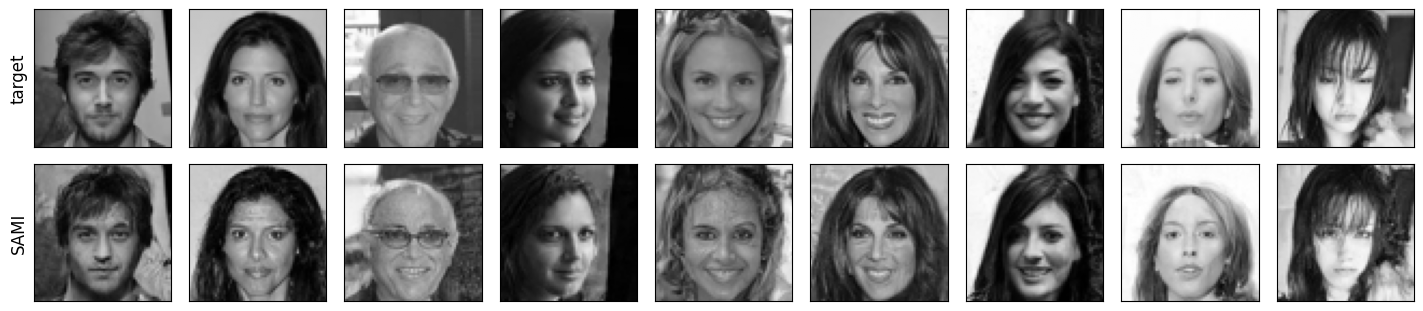

In [409]:
def reconstruct(model, targets, seed=0):
    '''targets in [0, 1], shape (N, 1, 64, 64); returns one conditional sample per target, in [0, 1]'''
    torch.manual_seed(seed)
    model.conditional_sample(len(targets), targets.to(device))  # no torch.no_grad(): the guidance uses autograd
    return model.x_t_history[-1].detach().cpu()

# img_idx = [345, 12, 1001, 5000, 7777, 15000]  # good ones: 345, 1001, 5000, 15000
# img_idx = [11, 888, 29, 45, 801, 13000]  # good ones: 11, 45, 801, 13000]
# img_idx = [345, 11, 12, 1001, 5000, 45, 801, 15000, 13000]
img_idx = [14001, 11, 12, 1001, 5000, 45, 801, 15000, 13000]
targets = test_imgs[img_idx]
recons = {'target': targets, 'SAMI': reconstruct(sami_ap, targets)}
# recons = {'target': targets, 'v77': reconstruct(v77, targets), 'SAMI': reconstruct(sami_ap, targets)}

fig, ax = plt.subplots(len(recons), len(img_idx), figsize=(1.6 * len(img_idx), 1.7 * len(recons)))
for r, (name, imgs) in enumerate(recons.items()):
    for c in range(len(img_idx)):
        ax[r, c].imshow(imgs[c, 0], cmap='gray', vmin=0, vmax=1)
        ax[r, c].set(xticks=[], yticks=[])
    ax[r, 0].set_ylabel(name)
plt.tight_layout()

plt.savefig(f'{plot_save_loc}/reconstruction_{img_idx}.pdf', dpi=300, bbox_inches='tight')


In [236]:
with torch.no_grad():
    x = sami_ap.scale_to_minus_one_to_one(test_imgs[:1000].to(device))  # the encoder expects [-1, 1]
    _, mu, var = sami_ap.encoder(x)
print(mu.shape, var.mean().item())


torch.Size([1000, 256]) 0.09105189889669418


# what to do now

- I need to see how the encoder posterior variance changes as a function of SNR
- I need to do interpolations between two images to show we learn a smooth latent space
- I need to measure how the squared norm of the guidance field changes as a function of noise level, for each latent axis. 
- I need to find two latent axes that correspond to different semantic attributes


## A: posterior variance vs SNR

loaded /mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/sami_autoprior_celeba_64/2-eager-eon-2-u02iqu2g/last.ckpt (epoch 330)


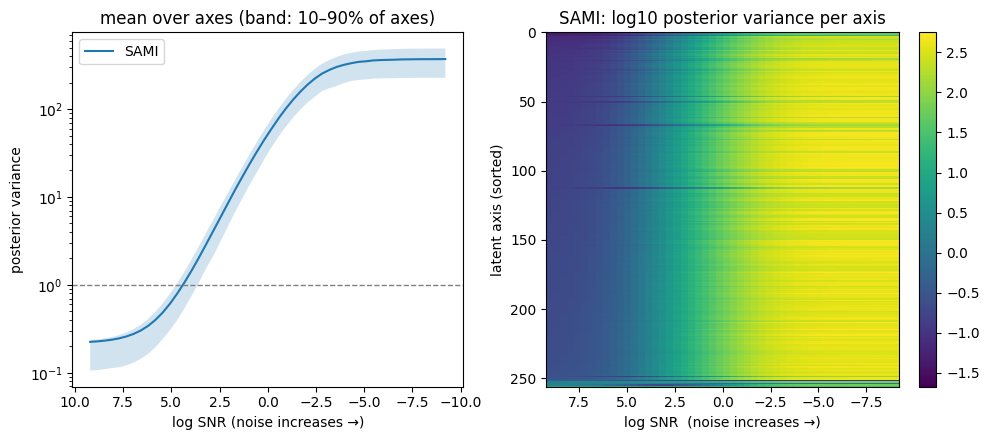

In [300]:
sami_ap, sami_config = load_trained_sami_autoprior(model_num=2, checkpoint="last", device=device)

import numpy as np
import d_analysis.utils.sami_autoprior as A

# models = {'v77': v77, 'SAMI': sami_ap}
models = {'SAMI': sami_ap}
# post = {name: A.posterior_variance_vs_snr(m, test_imgs[:1000], num_timesteps=50) for name, m in models.items()}
post = {name: A.posterior_variance_vs_snr(m, test_imgs[:1000], num_levels=50) for name, m in models.items()}



fig, axes = plt.subplots(1, 1+len(models), figsize=(10, 4.5))
for name, r in post.items():
    axes[0].plot(r['log_snr'], r['var'].mean(1), label=name)
    axes[0].fill_between(r['log_snr'], np.percentile(r['var'], 10, axis=1), np.percentile(r['var'], 90, axis=1), alpha=0.2)
axes[0].axhline(1, ls='--', c='gray', lw=1)
axes[0].set(yscale='log', xlabel='log SNR (noise increases →)', ylabel='posterior variance',
            title='mean over axes (band: 10–90% of axes)')
axes[0].invert_xaxis(); axes[0].legend()
for ax, (name, r) in zip(axes[1:], post.items()):
    order = np.argsort(r['var'][0])  # sort axes by their clean-image posterior variance
    A.plot_axes_vs_snr(r['var'], r['log_snr'], order=order, normalize=False, log_color=True,
                       title=f'{name}: log10 posterior variance per axis', ax=ax)
plt.tight_layout()

# save the plot
plt.savefig(f'{plot_save_loc}/posterior_variance_vs_snr.pdf', dpi=300, bbox_inches='tight')


## B: interpolations

SAMI 11 -> 801 consecutive-frame L2: [2.28 2.36 2.45 2.41 2.4  2.36 2.36 2.37]


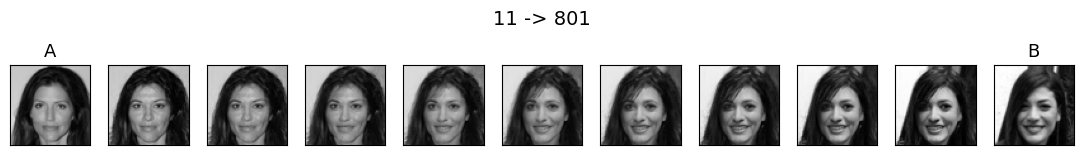

In [397]:
def plot_interpolation(rows, img_a, img_b, title=''):
    num_steps = len(next(iter(rows.values())))
    fig, ax = plt.subplots(len(rows), num_steps + 2, figsize=(1.0 * (num_steps + 2), 1.6 * len(rows)), squeeze=False)
    for r, (name, frames) in enumerate(rows.items()):
        for c, p in enumerate([img_a[0], *frames, img_b[0]]):
            ax[r, c].imshow(p[0], cmap='gray', vmin=0, vmax=1); ax[r, c].set(xticks=[], yticks=[])
        # ax[r, 0].set_ylabel(name)
        steps = (frames[1:] - frames[:-1]).flatten(1).norm(dim=1)
        print(f'{name} {title} consecutive-frame L2:', np.round(steps.numpy(), 2))
    ax[0, 0].set_title('A'); ax[0, -1].set_title('B')
    fig.suptitle(title)
    plt.tight_layout(); plt.show()
    return fig

import os
interp_path = 'd_analysis/sami_autoprior/interpolations.pt'
os.makedirs(os.path.dirname(interp_path), exist_ok=True)
interps = torch.load(interp_path) if os.path.exists(interp_path) else {}

pairs = [(11, 801)]  # test-set indices
num_steps = 9
for ia, ib in pairs:
    if (ia, ib) not in interps:
        img_a, img_b = test_imgs[ia:ia+1].clone(), test_imgs[ib:ib+1].clone()
        rows = {name: A.interpolate_images(m, img_a, img_b, num_steps=num_steps, method='linear', seed=0)
                for name, m in models.items()}
        interps[(ia, ib)] = {'rows': rows, 'img_a': img_a, 'img_b': img_b}
        torch.save(interps, interp_path)
    fig = plot_interpolation(**interps[(ia, ib)], title=f'{ia} -> {ib}')
    fig.tight_layout()

    fig.savefig(f'{plot_save_loc}/interpolation_{ia}_{ib}.pdf', dpi=300, bbox_inches='tight')


## C: per-axis guidance 

In [ ]:
import os, pickle
# guid_path = 'd_analysis/sami_autoprior/guidance_norms.pkl'
guid_path = 'd_analysis/sami_autoprior/guidance_norms_logsnr.pkl'

mode = 'load'

if mode == 'save':
    # COMPUTATION
    # guid = {name: A.guidance_norm_per_axis(m, test_imgs[:256], num_timesteps=40, batch_size=32, dim_chunk=32)
    #     for name, m in models.items()}
    guid = {name: A.guidance_norm_per_axis(m, test_imgs[:256], num_levels=60, batch_size=32, dim_chunk=32)
        for name, m in models.items()}
    # SAVE
    with open(guid_path, 'wb') as f:
        pickle.dump(guid, f)
    # os.makedirs(os.path.dirname(guid_path), exist_ok=True)
elif mode == 'load':
    # later, instead of recomputing:
    with open(guid_path, 'rb') as f: guid = pickle.load(f)

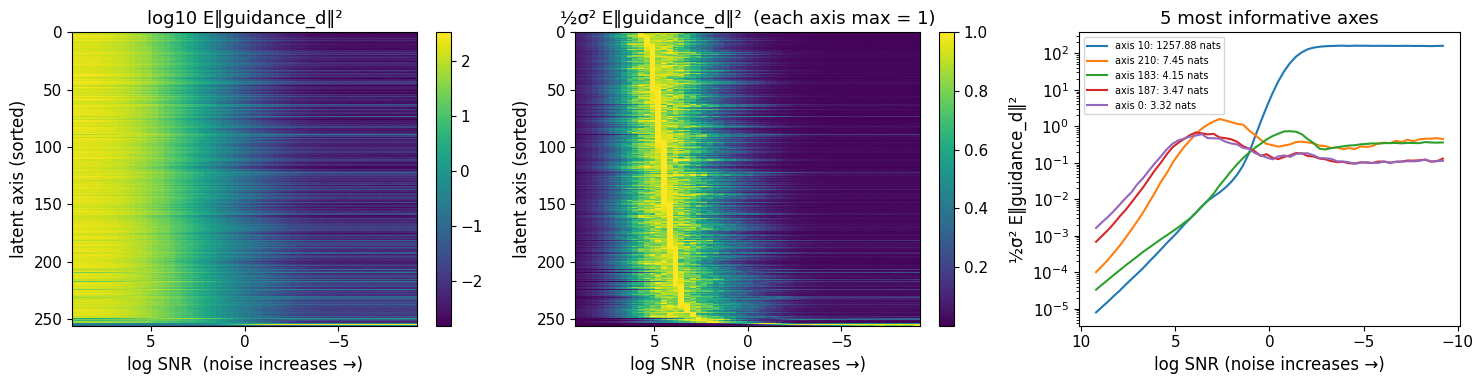

In [324]:
fig, axes = plt.subplots(len(guid), 3, figsize=(15, 4 * len(guid)), squeeze=False)
for row, (name, r) in zip(axes, guid.items()):
    peak = A.peak_log_snr(r['info_density'], r['log_snr'])
    order = np.argsort(-peak)  # axes that peak at high SNR (fine detail) at the top
    A.plot_axes_vs_snr(r['sq_norm'], r['log_snr'], order=order, normalize=False, log_color=True,
                       title=f'log10 E‖guidance_d‖²', ax=row[0])
    A.plot_axes_vs_snr(r['info_density'], r['log_snr'], order=order, normalize=True,
                       title=f'½σ² E‖guidance_d‖²  (each axis max = 1)', ax=row[1])
    info = A.per_axis_information(r)
    for d in np.argsort(-info)[:5]:
        row[2].plot(r['log_snr'], r['info_density'][:, d], label=f'axis {d}: {info[d]:.2f} nats')
    row[2].set(xlabel='log SNR (noise increases →)', ylabel='½σ² E‖guidance_d‖²', title=f'5 most informative axes')
    row[2].invert_xaxis(); row[2].legend(fontsize=7)
    row[2].set_yscale('log')
plt.tight_layout()

plt.savefig(f'{plot_save_loc}/guidance_norms.pdf', dpi=300, bbox_inches='tight')


SAMI: noise-tracking axes [ 10 116] (info [1257.9    1.7])


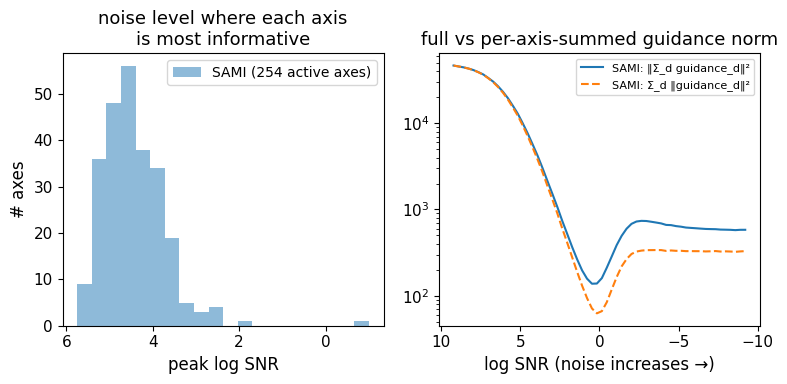

In [320]:
fig2, ax = plt.subplots(1, 2, figsize=(8, 4))
for name, r in guid.items():
    info = A.per_axis_information(r)
    peak = A.peak_log_snr(r['info_density'], r['log_snr'])
    # axes whose guidance is still near its maximum at pure noise respond to the noise level itself, not image content;
    # the information reading of ½σ²E‖g‖² doesn't hold for them, so show them separately
    noise_tracking = r['info_density'][-1] > 0.5 * r['info_density'].max(0)
    active = (info > 0.1) & ~noise_tracking  # absolute threshold in nats, so one outlier can't hide the rest
    print(f'{name}: noise-tracking axes {np.where(noise_tracking)[0]} (info {np.round(info[noise_tracking], 1)})')
    ax[0].hist(peak[active], bins=20, alpha=0.5, label=f'{name} ({active.sum()} active axes)')
    ax[1].plot(r['log_snr'], r['total_sq_norm'], label=f'{name}: ‖Σ_d guidance_d‖²')
    ax[1].plot(r['log_snr'], r['sq_norm'].sum(1), ls='--', label=f'{name}: Σ_d ‖guidance_d‖²')
ax[0].set(xlabel='peak log SNR', ylabel='# axes', title='noise level where each axis\nis most informative')
ax[0].invert_xaxis(); ax[0].legend()
ax[1].set(yscale='log', xlabel='log SNR (noise increases →)', title='full vs per-axis-summed guidance norm')
ax[1].invert_xaxis(); ax[1].legend(fontsize=8)
plt.tight_layout()

plt.savefig(f'{plot_save_loc}/latent_snr_analysis.pdf', dpi=300, bbox_inches='tight')


## compare signal variance vs noise variance 

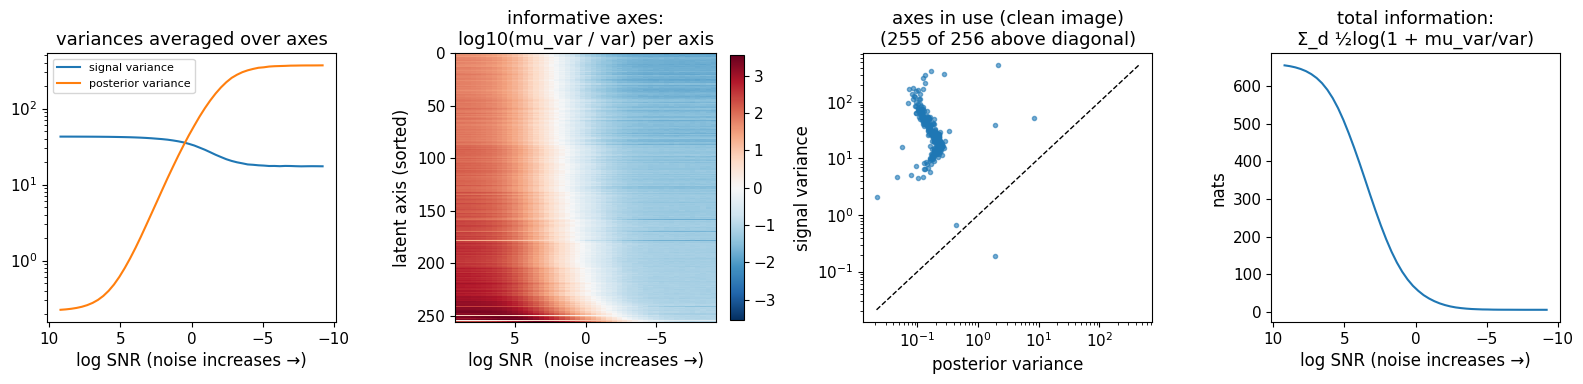

In [325]:
def latent_snr_crossing(ratio, log_snr, level=1.0):
    '''log SNR at which each axis's latent SNR (mu_var / var) first drops below level, going from clean to noisy.
    nan for axes that are below level even on clean images.'''
    first_below = np.argmax(ratio < level, axis=0)
    first_below[~(ratio < level).any(0)] = len(log_snr) - 1  # never drops below: use the noisiest level
    crossing = log_snr[first_below].astype(float)
    crossing[ratio[0] < level] = np.nan
    return crossing

fig, axes = plt.subplots(len(post), 4, figsize=(16, 4 * len(post)), squeeze=False)
for row, (name, r) in zip(axes, post.items()):
    ratio = r['mu_var'] / r['var']                # (T, D) signal / noise of each latent axis
    info = 0.5 * np.log1p(ratio)                   # Gaussian-channel estimate, nats per axis
    crossing = latent_snr_crossing(ratio, r['log_snr'])

    # 1) the two variances, averaged over axes
    row[0].plot(r['log_snr'], r['mu_var'].mean(1), label='signal variance')
    # row[0].plot(r['log_snr'], r['mu_var'].mean(1), label='across-image variance of mean')
    row[0].plot(r['log_snr'], r['var'].mean(1), label='posterior variance')
    row[0].set(yscale='log', xlabel='log SNR (noise increases →)', title=f'variances averaged over axes')
    row[0].invert_xaxis(); row[0].legend(fontsize=8)

    # 2) per-axis latent SNR, sorted by where it drops below 1
    order = np.argsort(-np.nan_to_num(crossing, nan=np.inf))  # longest-lived axes at the bottom, dead axes at the top
    A.plot_axes_vs_snr(np.log10(ratio), r['log_snr'], order=order, normalize=False, cmap='RdBu_r',
                       title=f'informative axes:\nlog10(mu_var / var) per axis', ax=row[1])
    lim = np.abs(np.log10(ratio)).max(); row[1].images[0].set_clim(-lim, lim)

    # 3) clean-image scatter: axes above the diagonal carry image information, below it are ~unused
    row[2].loglog(r['var'][0], r['mu_var'][0], '.', alpha=0.6)
    lo, hi = min(r['var'][0].min(), r['mu_var'][0].min()), max(r['var'][0].max(), r['mu_var'][0].max())
    row[2].plot([lo, hi], [lo, hi], 'k--', lw=1)
    row[2].set(xlabel='posterior variance', ylabel='signal variance',
               title=f'axes in use (clean image)\n({(ratio[0] > 1).sum()} of {ratio.shape[1]} above diagonal)')

    # 4) Gaussian estimate of the information in the latent, total over axes
    row[3].plot(r['log_snr'], info.sum(1))
    row[3].set(xlabel='log SNR (noise increases →)', ylabel='nats', title=f'total information:\nΣ_d ½log(1 + mu_var/var)')
    row[3].invert_xaxis()
plt.tight_layout()


mpl.rcParams['font.size'] = 12          # base size; most other sizes scale from it
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['figure.titlesize'] = 14   # fig.suptitle
plt.savefig(f'{plot_save_loc}/posterior_vs_signal_variance.pdf', dpi=300, bbox_inches='tight')


## semantic meaning of axes

can you generate images interpolated along the most informative N=5 axes? I want to see what semantics they correspond to

- A latent traversal will show this. For each of the top N axes, take an image's posterior mean, sweep that one coordinate while keeping the others fixed, and decode each point.
    - Sweep range: the 2nd–98th percentile of that axis's posterior mean across test images, so the values stay within what the encoder actually produces.
    - Shared noise: everything for one image (all 5 axes × all values, plus a plain reconstruction) is decoded in a single batch with the same noise, so each row changes only through its axis.
    - Axis ranking: the per-axis information from Cell C, leaving out the noise-tracking axes such as axis 10.


In [331]:
# N = 5
r = guid['SAMI']
axes_top = A.most_informative_axes(r, n=100)[5:10]               # excludes partly noise-tracking axes (noise_frac=0.1)
info = A.per_axis_information(r)
peak = A.peak_log_snr(r['info_density'], r['log_snr'])
print('axes:', axes_top, '| info (nats):', np.round(info[axes_top], 2), '| peak log SNR:', np.round(peak[axes_top], 2))

# sweep each axis over the range its posterior mean takes across test images
mus = A.encode_means(sami_ap, test_imgs[:2000]).cpu()    # (2000, D)
qs = torch.tensor([0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98])
values = torch.quantile(mus[:, axes_top], qs, dim=0)    # (Q, N)

base_idx = [345, 1001]  # test-set images to traverse
traversals = {}
for i in base_idx:
    img = test_imgs[i:i+1].clone()
    frames, recon = A.traverse_axes(sami_ap, img, axes_top, values, seed=0)
    traversals[i] = {'image': img, 'frames': frames, 'recon': recon}


axes: [ 40 102  43 198 111] | info (nats): [1.38 1.38 1.34 1.34 1.32] | peak log SNR: [4.04 3.94 3.69 4.21 3.73]


In [345]:
Q = len(qs)
for i, t in traversals.items():
    own = A.encode_mean(sami_ap, t['image'])[0].cpu()
    fig, ax = plt.subplots(N, Q + 2, figsize=(1.3 * (Q + 2), 1.4 * N), squeeze=False)
    for k, d in enumerate(axes_top):
        ax[k, 0].imshow(t['image'][0, 0], cmap='gray', vmin=0, vmax=1)
        ax[k, 1].imshow(t['recon'][0, 0], cmap='gray', vmin=0, vmax=1)
        for q in range(Q):
            ax[k, q + 2].imshow(t['frames'][k, q, 0], cmap='gray', vmin=0, vmax=1)
        own_pct = (mus[:, d] < own[d]).float().mean().item() * 100  # where this image sits on axis d
        ax[k, 0].set_ylabel(f'axis {d}\n{info[d]:.1f} nats\nimg @ {own_pct:.0f}%', fontsize=8)
    for a in ax.flat:
        a.set(xticks=[], yticks=[])
    ax[0, 0].set_title('image', fontsize=8); ax[0, 1].set_title('recon', fontsize=8)
    for q in range(Q):
        ax[0, q + 2].set_title(f'{qs[q] * 100:.0f}%', fontsize=8)
    fig.suptitle(f'test image {i}: each axis swept over its 2–98% range across images', fontsize=10)
    plt.tight_layout(); plt.show()


IndexError: index 40 is out of bounds for axis 0 with size 40

Error in callback <function flush_figures at 0x15543c934b80> (for post_execute):


KeyboardInterrupt: 

How to read it:
- Layout: each row sweeps one axis. The column headers are that axis's percentiles across test images, and the row label gives the axis number, its nats and where this image already sits on the axis.
- Shared noise: all rows and the "recon" column use the same noise, so differences come only from the axis being swept.
- Runtime: each base image is one 1000-step sampling run on a batch of 36.
- Checking an interpretation: try several base images. An axis that means something should change the same attribute in all of them.

What the ranking means:
- Excluded axes: the default leaves out axes that carry more than 10% of their peak guidance at pure noise. On your saved results that includes 210, 138, 0 and 187, which would otherwise be near the top: they get 29–39% of their "information" from the noisy half, against about 5% for a typical axis.
- Resulting top 5 (current saved results): 108, 163, 156, 123 and 20, at about 2.4–2.6 nats each.
- Weak ranking: the next axes carry almost as much, so information is spread fairly evenly and the ranking is only rough. Any strong axis is worth traversing.
- The excluded axes are still worth a look. Axes that partly track noise level often respond to global image statistics such as contrast, brightness or sharpness. A.most_informative_axes(r, n=N, noise_frac=0.5) gives 210, 138, 0, 187, 108, and passing a list such as axes_top = np.array([10, 210, 138]) sweeps any axes you choose.

## find the axes that result in the largest effect by MSE

can you give me code that will generate images at only 2% and 98% of the range, across N=40 latents, and find the latent where the two images are the most different (by mse)? i'm trying to find the latent that has the largest effect on the images, and things like global light direction should have the largest effect.

- Each pair of rows changes only its own axis, and the last row is the unmodified reconstruction.
- At a mid noise level, the guidance for the 2% and 98% latents differs by about 45% of its norm, so the full 1000-step sampler will respond.
- The zero MSEs were only because the 3-step test sampler barely applies guidance.

In [343]:
N = 256
cand_axes = np.arange(N)
# cand_axes = A.most_informative_axes(r, n=N, noise_frac=None)   # no noise-tracking filter: global-lighting axes can look noise-tracking
mus = A.encode_means(sami_ap, test_imgs[:2000]).cpu()
values = torch.quantile(mus[:, cand_axes], torch.tensor([0.02, 0.98]), dim=0)   # (2, N): each axis's 2% and 98% values

base_idx = [345, 1001, 12, 5000]   # average the effect over a few faces
extremes = {}
pair_mse = []
for i in base_idx:
    img = test_imgs[i:i+1].clone()
    frames, recon = A.traverse_axes(sami_ap, img, cand_axes, values, seed=0)   # frames: (N, 2, 1, H, W)
    extremes[i] = {'image': img, 'frames': frames, 'recon': recon}
    pair_mse.append((frames[:, 0] - frames[:, 1]).pow(2).flatten(1).mean(1))
pair_mse = torch.stack(pair_mse)                  # (num_images, N)
mean_mse, std_mse = pair_mse.mean(0), pair_mse.std(0)
rank = torch.argsort(mean_mse, descending=True)
for j in rank[:10].tolist():
    print(f'axis {cand_axes[j]:3d}: MSE(2%, 98%) = {mean_mse[j]:.4f} ± {std_mse[j]:.4f}   per image {np.round(pair_mse[:, j].numpy(), 4)}')


axis 210: MSE(2%, 98%) = 0.2255 ± 0.0382   per image [0.2146 0.2807 0.1925 0.2144]
axis 138: MSE(2%, 98%) = 0.0863 ± 0.0214   per image [0.1018 0.0553 0.0991 0.089 ]
axis 187: MSE(2%, 98%) = 0.0762 ± 0.0057   per image [0.0787 0.0717 0.0714 0.0831]
axis   0: MSE(2%, 98%) = 0.0647 ± 0.0102   per image [0.0704 0.0494 0.0693 0.0697]
axis 120: MSE(2%, 98%) = 0.0389 ± 0.0036   per image [0.0417 0.0338 0.0391 0.0411]
axis 154: MSE(2%, 98%) = 0.0298 ± 0.0015   per image [0.0297 0.0278 0.0304 0.0315]
axis  68: MSE(2%, 98%) = 0.0269 ± 0.0019   per image [0.027  0.0283 0.0242 0.0282]
axis 200: MSE(2%, 98%) = 0.0188 ± 0.0023   per image [0.0192 0.0154 0.02   0.0205]
axis 108: MSE(2%, 98%) = 0.0164 ± 0.0022   per image [0.016  0.0135 0.0174 0.0187]
axis 134: MSE(2%, 98%) = 0.0152 ± 0.0019   per image [0.0155 0.0126 0.0155 0.0171]


In [344]:
import os
sweep_path = 'd_analysis/sami_autoprior/axis_sweep_256.pt'
os.makedirs(os.path.dirname(sweep_path), exist_ok=True)
torch.save({
    'extremes': extremes,            # per base image: image, frames (N, 2, 1, H, W), recon
    'pair_mse': pair_mse,            # (num_images, N)
    'cand_axes': cand_axes,
    'values': values,                # (2, N) the 2% / 98% values that were decoded
    'base_idx': base_idx,
    'checkpoint': 'epoch_284',   # <- whichever checkpoint sami_ap was loaded from
}, sweep_path)


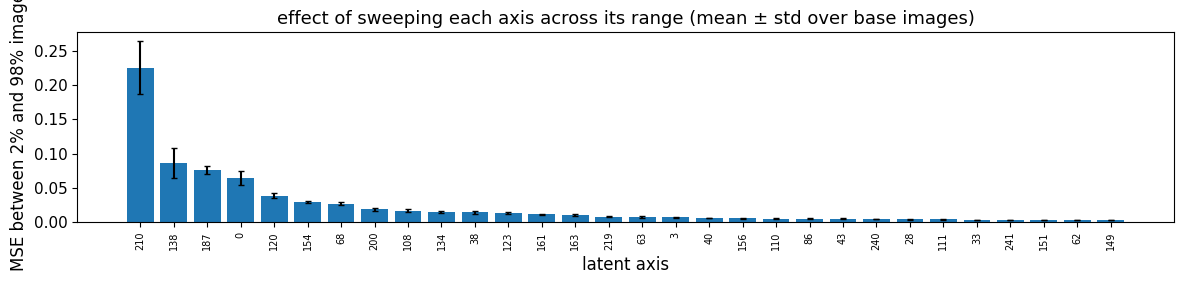

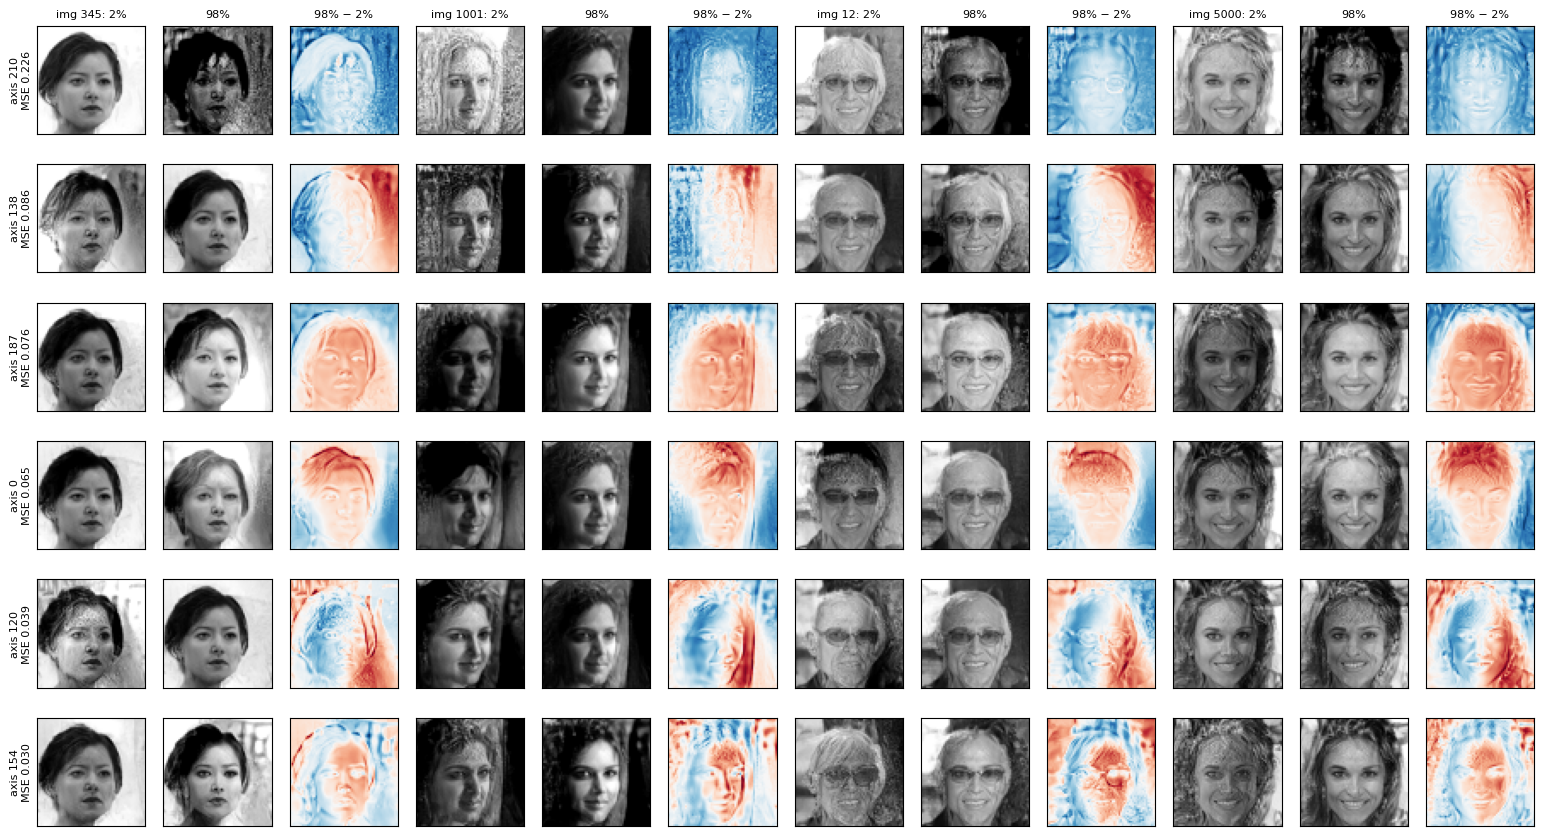

In [348]:
# all axes, sorted by effect size
fig, ax = plt.subplots(figsize=(12, 3))

M = 30
ax.bar(range(M), mean_mse[rank[:M]], yerr=std_mse[rank[:M]], capsize=2)
# ax.bar(range(N), mean_mse[rank], yerr=std_mse[rank], capsize=2)
# ax.set(xticks=range(N), xlabel='latent axis', ylabel='MSE between 2% and 98% images',
ax.set(xticks=range(M), xlabel='latent axis', ylabel='MSE between 2% and 98% images',
       title='effect of sweeping each axis across its range (mean ± std over base images)')
ax.set_xticklabels([str(cand_axes[j]) for j in rank[:M].tolist()], rotation=90, fontsize=7)
plt.tight_layout()

plt.savefig(f'{plot_save_loc}/axis_sweep_effects_mse.pdf', dpi=300, bbox_inches='tight')

# the K largest-effect axes: 2% image, 98% image and their difference, for each base image
K = 6
fig, ax = plt.subplots(K, 3 * len(base_idx), figsize=(1.3 * 3 * len(base_idx), 1.45 * K), squeeze=False)
for k, j in enumerate(rank[:K].tolist()):
    for b, i in enumerate(base_idx):
        lo, hi = extremes[i]['frames'][j, 0, 0], extremes[i]['frames'][j, 1, 0]
        diff = hi - lo
        lim = diff.abs().max().item() + 1e-8
        ax[k, 3 * b].imshow(lo, cmap='gray', vmin=0, vmax=1)
        ax[k, 3 * b + 1].imshow(hi, cmap='gray', vmin=0, vmax=1)
        ax[k, 3 * b + 2].imshow(diff, cmap='RdBu_r', vmin=-lim, vmax=lim)
        if k == 0:
            ax[k, 3 * b].set_title(f'img {i}: 2%', fontsize=8); ax[k, 3 * b + 1].set_title('98%', fontsize=8)
            ax[k, 3 * b + 2].set_title('98% − 2%', fontsize=8)
    ax[k, 0].set_ylabel(f'axis {cand_axes[j]}\nMSE {mean_mse[j]:.3f}', fontsize=8)
for a in ax.flat:
    a.set(xticks=[], yticks=[])
plt.tight_layout()

plt.savefig(f'{plot_save_loc}/axis_sweep_effects.pdf', dpi=300, bbox_inches='tight')


Reading the difference maps: the "98% − 2%" column shows where an axis changes the image, in red and blue. A light-direction axis should show a smooth gradient across the whole face, one side brightening while the other darkens. It should look the same for every base image. Axes that change a local feature (mouth, eyes, hair edge) give compact blobs instead.

## alignment between measures and with the observed change

do these large effect axes correspond to those axes that have peak sensitivity at medium to large SNR? To test this, relate each axis's effect size (the 2%-vs-98% MSE) to where its guidance sensitivity peaks along log SNR.

In [349]:
# r_now = A.guidance_norm_per_axis(sami_ap, test_imgs[:256], num_levels=60, batch_size=32,
#                                  dim_chunk=40, axes=cand_axes)
r_now = A.guidance_norm_per_axis(sami_ap, test_imgs[:256], num_levels=60, batch_size=32,
                                 dim_chunk=40)  # all axes, not just the candidate axes
with open('d_analysis/sami_autoprior/guidance_norms_all_axes.pkl', 'wb') as f:
    pickle.dump({'r_now': r_now, 'mean_mse': mean_mse, 'std_mse': std_mse}, f)

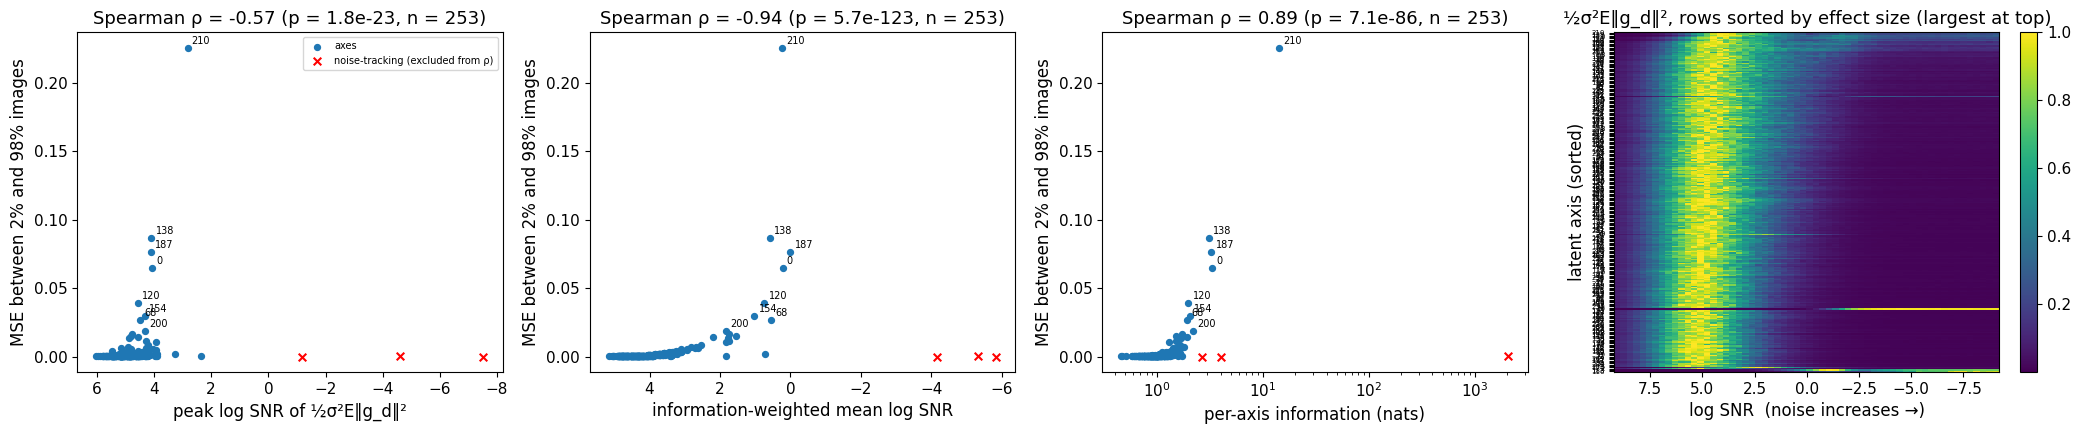

In [410]:
from scipy.stats import spearmanr

assert np.array_equal(r_now['axes'], cand_axes)   # columns line up with the MSE analysis
effect = mean_mse.numpy()
peak = A.peak_log_snr(r_now['info_density'], r_now['log_snr'])
centroid = A.centroid_log_snr(r_now)
info = A.per_axis_information(r_now)
noise_track = A.noise_tracking_axes(r_now)          # the extreme noise-level axes (like axis 10)
keep = ~noise_track
N = len(cand_axes)

fig, ax = plt.subplots(1, 4, figsize=(21, 4.5))
for a, (x, xlabel) in zip(ax[:3], [(peak, 'peak log SNR of ½σ²E‖g_d‖²'),
                                   (centroid, 'information-weighted mean log SNR'),
                                   (info, 'per-axis information (nats)')]):
    rho, p = spearmanr(x[keep], effect[keep])
    a.scatter(x[keep], effect[keep], s=18, label='axes')
    a.scatter(x[noise_track], effect[noise_track], s=30, marker='x', c='r', label='noise-tracking (excluded from ρ)')
    for j in np.argsort(-effect)[:8]:
        a.annotate(str(cand_axes[j]), (x[j], effect[j]), fontsize=7, xytext=(3, 3), textcoords='offset points')
    a.set(xlabel=xlabel, ylabel='MSE between 2% and 98% images', title=f'Spearman ρ = {rho:.2f} (p = {p:.2g}, n = {keep.sum()})')
    if 'log SNR' in xlabel:
        a.invert_xaxis()   # noise increases to the right
a.set_xscale('log')
ax[0].legend(fontsize=7)

# sensitivity profiles with axes sorted by effect size (largest effect at the top)
A.plot_axes_vs_snr(r_now['info_density'], r_now['log_snr'], order=np.argsort(-effect), normalize=True,
                   title='½σ²E‖g_d‖², rows sorted by effect size (largest at top)', ax=ax[3])
ax[3].set_yticks(np.arange(N) + 0.5); ax[3].set_yticklabels(cand_axes[np.argsort(-effect)], fontsize=5)
plt.tight_layout()

plt.savefig(f'{plot_save_loc}/guidance_norms_vs_axis_effect.pdf', dpi=300, bbox_inches='tight')


Reading the correlation:

- Sign of ρ: ρ is computed on raw log SNR. A negative ρ in the first two panels means axes with larger effects have their information at lower SNR, i.e. they survive more noise. Because the x-axes are flipped so noise increases to the right, that shows up as points rising towards the right.
- What your hypothesis predicts: large global changes such as light direction are low-frequency, and low frequencies survive noise, so it predicts ρ < 0. That would put the sensitivity at medium to low SNR, not at the clean end.
- Heatmap: the fourth panel shows the same thing directly. If the hypothesis holds, the bright band moves to the right towards the top rows.
Caveats:

Caveats:
- Built-in bias: pixel MSE naturally favours spatially extended, low-frequency changes. So some correlation is expected by construction; test that the relationship is actually monotone rather than just present.
- Sample size: with 40 axes and 4 base images, n is small. Treat |ρ| below about 0.3 as inconclusive.
- Noise-tracking axes: the red crosses are left out of ρ. Their "information" isn't meaningful, but a large MSE for them is still a real effect, so check where they fall.

what is the X and Y axes of the 3 correlation plots? what are each of the plots trying to tell me?

All three scatter plots share the same y-axis and the same points. They differ in what goes on the x-axis.

Common to all three:
- Each point is one of the 40 candidate latent axes.
- Y-axis: effect size. The mean MSE between the image decoded with that axis at its 2% value and at its 98% value, averaged over your base images. Pixels are in [0, 1], so it's in squared-intensity units. Higher means changing this axis alters the image more.
- Red crosses are the extreme noise-level axes (like axis 10). They're shown but left out of the correlation.
- Labels mark the 8 axes with the largest effect.
- Title: Spearman ρ, the rank correlation between x and y over the non-red points, with its p-value and n. It asks only whether the rankings agree, not whether the relationship is linear.

Panel 1: x = peak log SNR of ½σ²E‖g_d‖²
- What x is: the noise level where the axis's guidance sensitivity is highest, i.e. the noise level at which that axis's information is being destroyed fastest. The axis is flipped: clean images (high SNR) on the left, noisier to the right.
- The question: do the axes that change the image most do their work at noisier levels? Coarse, global features such as light direction survive more noise, so your hypothesis predicts large-effect axes towards the right.
- Reading the sign: ρ is computed on raw log SNR, so the prediction corresponds to ρ < 0. Because the x-axis is flipped, that looks like points rising towards the right.

Panel 2: x = information-weighted mean log SNR (centroid)
- The question: the same as panel 1, measured a different way. The peak can jump around when an axis's curve is broad or has two humps; the centroid averages over the whole curve, so it's more stable.
- Reading it: same orientation and sign as panel 1. If both show the same trend, the conclusion doesn't depend on how "location" is measured. - If they disagree, trust the centroid more, and look at those axes' curves in the heatmap (panel 4).

Panel 3: x = per-axis information (nats, log scale)
- The question: a control. Maybe large-effect axes simply carry more information overall, whatever the noise level. Here x is how much the axis encodes, not where along the noise scale.
- Reading it: the x-axis isn't flipped here, so ρ > 0 means axes with more information have larger effects.

Panel 4:
- the heatmap, shows the full sensitivity curves behind panels 1 and 2. Rows are sorted by effect size, largest at the top. If your hypothesis holds, the bright band moves to the right (towards noise) as you go up the rows.

what if panel 1 is -0.34, panel 2 is -0.87, and panel 3 is 0.7?

Mostly this supports your hypothesis, but one confound needs checking.

Panel 2 (ρ = −0.87): strong support. The axes with the largest effects have their information centred at noisier levels, as expected for coarse, global features like lighting.

Panel 1 (ρ = −0.34) being much weaker isn't a contradiction. It tells you about the shape of the curves. The histogram earlier showed that almost all axes peak in a narrow band around log SNR 3.5–5. So the peak barely separates axes. The large-effect axes differ mainly in having a heavier tail extending into high noise. That tail moves the centroid but not the peak. In other words, large-effect axes also respond to fine detail, but they keep carrying information after the other axes have lost theirs.

Panel 3 (ρ = +0.7) is the confound. A heavy tail at the noisy end mechanically does two things at once: it adds to the integrated information, and it pulls the centroid towards noise. So centroid and information are probably correlated with each other, and you can't yet tell which one drives the effect size.

Two further checks:

- Partial correlations show whether each measure still predicts effect size once the other is held fixed.
- Robustness to partly noise-tracking axes. Earlier, axes 210, 138, 0 and 187 got 29–39% of their "information" from the noisy half, against about 5% for a typical axis. If those are your large-effect axes, their tails might partly come from the noise-tracking artefact rather than from coarse image content. Rerunning with the stricter 10% exclusion tests whether ρ survives without them.



--- exclude >50% at pure noise: n = 253
  ρ(effect, centroid)          = -0.94
  ρ(effect, info)              = +0.89
  ρ(centroid, info)            = -0.83   <- how confounded the two are
  ρ(effect, centroid | info)   = -0.90 (p = 6.7e-93)
  ρ(effect, info | centroid)   = +0.76 (p = 3.4e-49)
  excluded axes: [ 10 116 183]
--- exclude >10% at pure noise: n = 238
  ρ(effect, centroid)          = -0.93
  ρ(effect, info)              = +0.87
  ρ(centroid, info)            = -0.80   <- how confounded the two are
  ρ(effect, centroid | info)   = -0.90 (p = 7.8e-86)
  ρ(effect, info | centroid)   = +0.77 (p = 3.2e-48)
  excluded axes: [  0  10  38  68 108 116 120 123 134 138 154 161 163 183 187 200 210 244]


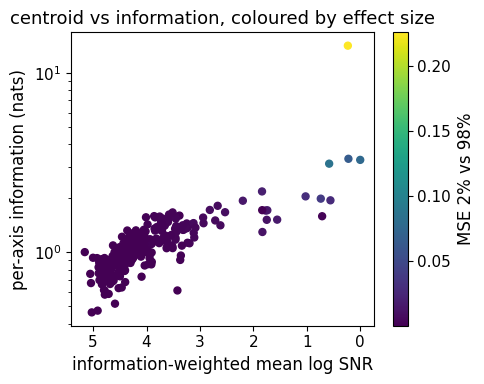

In [355]:
from scipy.stats import spearmanr, rankdata

def partial_spearman(x, y, control):
    '''rank correlation of x and y after regressing both (as ranks) on control (as ranks)'''
    rx, ry, rc = rankdata(x), rankdata(y), rankdata(control)
    resid = lambda a: a - np.polyval(np.polyfit(rc, a, 1), rc)
    return spearmanr(resid(rx), resid(ry))  # p-value is approximate (ignores the one lost degree of freedom)

for label, excl in [('exclude >50% at pure noise', A.noise_tracking_axes(r_now, frac=0.5)),
                    ('exclude >10% at pure noise', A.noise_tracking_axes(r_now, frac=0.1))]:
    k = ~excl
    e, c, inf_ = effect[k], centroid[k], info[k]
    print(f'--- {label}: n = {k.sum()}')
    print(f'  ρ(effect, centroid)          = {spearmanr(c, e)[0]:+.2f}')
    print(f'  ρ(effect, info)              = {spearmanr(inf_, e)[0]:+.2f}')
    print(f'  ρ(centroid, info)            = {spearmanr(c, inf_)[0]:+.2f}   <- how confounded the two are')
    rho, p = partial_spearman(c, e, inf_);  print(f'  ρ(effect, centroid | info)   = {rho:+.2f} (p = {p:.2g})')
    rho, p = partial_spearman(inf_, e, c);  print(f'  ρ(effect, info | centroid)   = {rho:+.2f} (p = {p:.2g})')
    print('  excluded axes:', cand_axes[excl])

fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(centroid[keep], info[keep], c=effect[keep], cmap='viridis', s=25)
ax.set(xlabel='information-weighted mean log SNR', ylabel='per-axis information (nats)', yscale='log',
       title='centroid vs information, coloured by effect size')
ax.invert_xaxis(); plt.colorbar(sc, label='MSE 2% vs 98%'); plt.tight_layout(); plt.show()


These results support your hypothesis, and they're stronger than the raw numbers suggested.

1. Scale predicts effect size, independently of information.
ρ(effect, centroid | info) is −0.83, and −0.94 under the stricter exclusion. Holding information fixed, axes whose information sits at noisier levels change the image much more. The raw correlation barely moves when the 18 partly noise-tracking axes are removed (−0.87 → −0.89), so it isn't driven by the noise-level artefact.

2. The confound came from the noise-tracking axes.
ρ(centroid, info) drops from −0.64 to −0.14 under the stricter exclusion. That fits what I suspected: axes with a tail towards pure noise get extra "information" and a shifted centroid at the same time, which couples the two measures. Without those axes, centroid and information are nearly independent, and centroid still predicts effect size strongly. That's the cleanest version of the test.

3. Information also contributes, separately from scale.
ρ(effect, info | centroid) is +0.60 and +0.72, so this is the "both contribute" case. That makes sense: MSE between the 2% and 98% images grows with how spatially extended a change is (scale), and with how many distinguishable states the axis spans across its range (information). The raw ρ(effect, info) fell from 0.70 to 0.47 under strict exclusion, but the partial went up. So some of the raw information correlation was just coarse axes also having inflated information.

(array([210,   0, 187, 138, 200, 154, 120,  68,  38,   3]),
 array([14.14092636,  3.31487966,  3.26857853,  3.11360598,  2.18077779,
         2.04681396,  1.98815727,  1.946141  ,  1.93579257,  1.81394291]),
 array([0.12092709, 0.02629115, 0.03650422, 0.03091594, 0.00684046,
        0.01889994, 0.01309829, 0.01402112, 0.00517504, 0.00284686],
       dtype=float32))

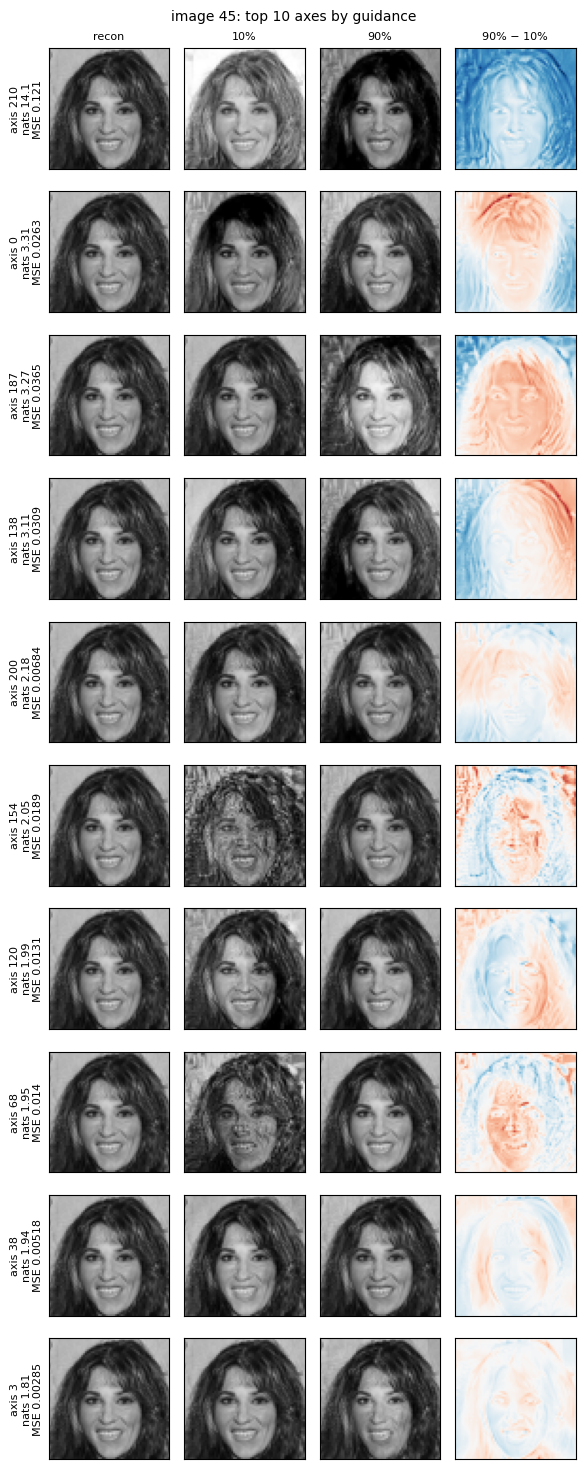

In [363]:
# rank by the effect on this image (decodes every candidate axis at 2% and 98%)
# out = A.top_axis_extremes(sami_ap, test_imgs, idx=1001, method='mse')

# rank by latent SNR (encoder only, cheap), with different percentiles
# out = A.top_axis_extremes(sami_ap, test_imgs, idx=1001, method='variance', lo=0.05, hi=0.95)

# rank by integrated ½σ²E‖g_d‖², reusing a guidance result from the SAME checkpoint
# out = A.top_axis_extremes(sami_ap, test_imgs, idx=11, method='guidance', K=10, guidance_result=r_now, lo=0.10, hi=0.90)
out = A.top_axis_extremes(sami_ap, test_imgs, idx=45, method='guidance', K=10, guidance_result=r_now, lo=0.10, hi=0.90)

# img_idx = [345, 11, 12, 1001, 5000, 45, 801, 15000, 13000]
# ,
                        #   save_path=f'{plot_save_loc}/axis_extremes_1001_guidance.pdf')

out['axes'], out['scores'], out['mse']   # chosen axes, their ranking scores, MSE between their 2% and 98% images


## linear combination of features

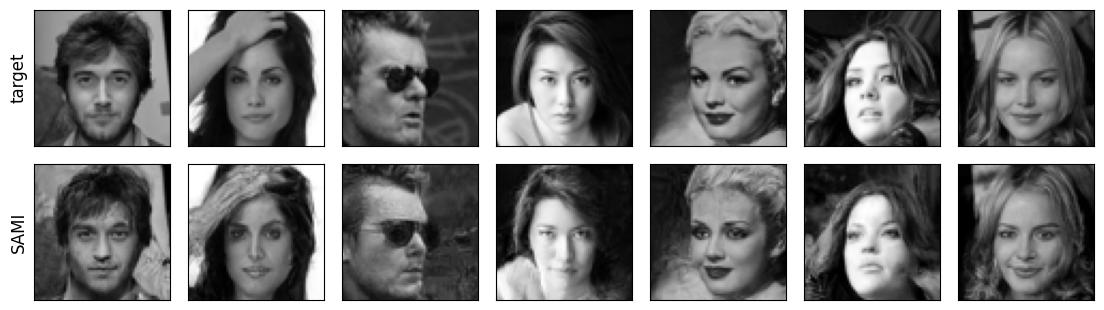

In [408]:
def reconstruct(model, targets, seed=0):
    '''targets in [0, 1], shape (N, 1, 64, 64); returns one conditional sample per target, in [0, 1]'''
    torch.manual_seed(seed)
    model.conditional_sample(len(targets), targets.to(device))  # no torch.no_grad(): the guidance uses autograd
    return model.x_t_history[-1].detach().cpu()

# img_idx = [345, 11, 12, 1001, 5000, 45, 801, 15000, 13000]

img_idx = [14001, 1402, 1403, 1404, 1405, 1407, 13008]

targets = test_imgs[img_idx]
recons = {'target': targets, 'SAMI': reconstruct(sami_ap, targets)}
# recons = {'target': targets, 'v77': reconstruct(v77, targets), 'SAMI': reconstruct(sami_ap, targets)}

fig, ax = plt.subplots(len(recons), len(img_idx), figsize=(1.6 * len(img_idx), 1.7 * len(recons)))
for r, (name, imgs) in enumerate(recons.items()):
    for c in range(len(img_idx)):
        ax[r, c].imshow(imgs[c, 0], cmap='gray', vmin=0, vmax=1)
        ax[r, c].set(xticks=[], yticks=[])
    ax[r, 0].set_ylabel(name)
plt.tight_layout()


In [402]:
idx = 13006
axis_a, axis_b = 210, 138                 # rows (down) and columns (right)
# axis_a, axis_b = 187, 138                 # rows (down) and columns (right)
steps_a = [0, -.8, -1.6]                    # offsets in σ (the axis's std across images) from the image's own value
steps_b = [0, 1, 2]                    # set each separately to control how far each axis moves

img = test_imgs[idx:idx+1].clone()
grid, values_a, values_b = A.traverse_two_axes(sami_ap, img, axis_a, axis_b, steps_a, steps_b,
                                               ref_mus=mus, units='std', cells='cross', seed=0)

# grid, values_a, values_b = A.traverse_two_axes(sami_ap, img, axis_a, axis_b, steps_a, steps_b,
                                            #    ref_mus=mus, units='std', cells='full', seed=0)
print(f'axis {axis_a} values:', values_a.numpy().round(2), f'| axis {axis_b} values:', values_b.numpy().round(2))
print('non-additivity along the diagonal:', A.two_axis_interaction(grid).round(3))


axis 210 values: [42.63 25.75  8.87] | axis 138 values: [ 2.9  21.43 39.97]
non-additivity along the diagonal: [0.074 0.114]


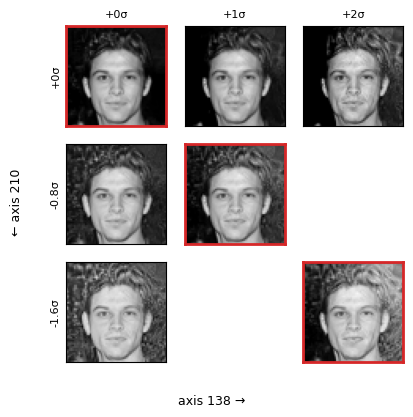

In [407]:
fig = A.plot_two_axis_grid(grid, axis_a, axis_b, steps_a, steps_b, units='std',
                        #    title=f'image {idx}: axis {axis_a} × axis {axis_b}',
                           save_path=f'{plot_save_loc}/two_axis_{axis_a}_{axis_b}_img{idx}.pdf')
# plt.show()
# fig.tight_layout()

fig.savefig(f'{plot_save_loc}/two_axis_{axis_a}_{axis_b}_img{idx}.pdf', dpi=300, bbox_inches='tight')

## also want to figure out what the axis that lies below the diagonal means in signal vs variance

# prev

In [220]:
model_name= 'autoprior_celeba_64'  # for 64x64 uncond
model_alias= 'v77'  # 256 dim latent space, KL = 1e-3, kernels = 64  -> produces images that are very similar to input
entity = 'blyo'
project = model_artifact_name = model_name

# DOWNLOAD ARTIFACT (WEIGHTS) AND MODEL CONFIG (ARGS)
from b_models.autoprior.utils import load_model_args_from_artifact
config, args, model_path = load_model_args_from_artifact(entity, project, model_artifact_name, model_alias)

# LOAD MODEL WEIGHTS
from b_models.autoprior.utils import load_autoprior_weights
autoprior = load_autoprior_weights(args, model_path, device)
autoprior.eval();

wandb: Downloading large artifact autoprior_celeba_64:v77, 137.25MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.4


In [231]:
config

{'lr': 0.001,
 'bias': False,
 'lr_end': 0.001,
 'epsilon': 0.0001,
 'padding': 1,
 'rescale': True,
 'bias_rec': False,
 'dir_name': 'models/saved_models/autoprior_celeba_64:celeba-64x64-60000',
 'data_name': 'celeba',
 'timesteps': 1000,
 'batch_size': 512,
 'image_dims': 64,
 'noise_dist': 'cosine_in_alpha_bar',
 'num_blocks': 3,
 'num_epochs': 5000,
 'save_every': 500,
 'beta_minmax': [0.0001, 0.02],
 'denoiser_rf': 68,
 'kernel_size': 3,
 'latent_dims': 256,
 'latent_rank': 16,
 'num_kernels': 128,
 'padding_rec': 1,
 'pool_window': 2,
 'kl_reduction': 'sum',
 'num_channels': 1,
 'num_dec_conv': 2,
 'num_enc_conv': 2,
 'num_mid_conv': 2,
 'sigma_minmax': [0.0001, 0.9999],
 'use_full_cov': False,
 'weighted_MSE': False,
 'encoder_model': 'half_unet',
 'kl_weight_end': 0.001,
 'time_channels': 64,
 'trainset_size': 60000,
 'activation_rec': 'relu',
 'data_root_path': '/tmp',
 'denoiser_model': 'unet',
 'num_blocks_rec': 3,
 'denoiser_target': 'noise',
 'kernel_size_rec': 3,
 'kl_wei

In [ ]:
from a_datasets.celeba_color.data import load_celeba_data

test_subset = load_celeba_data(
    grayscale = True,
    img_size = 64,
    split = "test",
    num_workers = 4,
)

# from celeba.utils.dataset import select_target_img
# start_seed = 1
start_img_idx = 345
# start_img = select_target_img(test_subset, img_idx=start_img_idx, seed=start_seed, plot=False, device=device)
# print(start_img.shape)

start_img = test_subset[start_img_idx].unsqueeze(0).to(device)
print(start_img.shape)
print(start_img.min(), start_img.max())

from b_models.autoprior.utils import make_presentable
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
start_img_view = make_presentable(start_img)
print(start_img_view.shape)
ax.imshow(start_img_view[0], cmap='gray')
ax.axis('off')
plt.show()
# fig.savefig(f'celeba/figures/celeba_start_img_seed={start_seed}-img_idx={start_img_idx}.pdf', 
#             bbox_inches='tight', 
#             transparent=True,
#             dpi=300)

torch.Size([1, 1, 64, 64])
(1, 64, 64, 1)


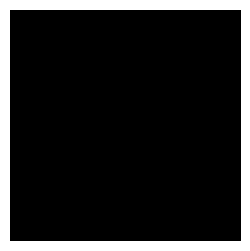

In [ ]:
from a_datasets.celeba import select_target_img
start_seed = 1
start_img_idx = 345
start_img = select_target_img(test_subset, img_idx=start_img_idx, seed=start_seed, plot=False, device=device)
print(start_img.shape)

from b_models.autoprior.utils import make_presentable
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
start_img_view = make_presentable(start_img)
print(start_img_view.shape)
ax.imshow(start_img_view[0], cmap='gray')
ax.axis('off')
plt.show()
# fig.savefig(f'celeba/figures/celeba_start_img_seed={start_seed}-img_idx={start_img_idx}.pdf', 
#             bbox_inches='tight', 
#             transparent=True,
#             dpi=300)

In [ ]:
# DOWNLOAD DATASET
from celeba.utils.dataset import get_celeba_dataset
train_subset, test_subset = get_celeba_dataset(config['image_dims'], config['trainset_size'])